In [4]:
import tensorflow as tf
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [5]:
import matplotlib.pyplot as plt
def show_digit(index, X_data, y_true, y_pred):
    """
    Displays an 8x8 digit image with true and predicted labels.
    """
    image = X_data[index].reshape(8, 8)

    plt.imshow(image, cmap='gray')
    plt.title(f"True: {y_true[index]} | Pred: {y_pred[index]}")
    plt.axis('off')
    plt.show()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5132 - loss: 2.1517 - val_accuracy: 0.8264 - val_loss: 0.5598
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8847 - loss: 0.4029 - val_accuracy: 0.8958 - val_loss: 0.4198
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9352 - loss: 0.2475 - val_accuracy: 0.9306 - val_loss: 0.2217
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9454 - loss: 0.1883 - val_accuracy: 0.9583 - val_loss: 0.1617
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9634 - loss: 0.1424 - val_accuracy: 0.9306 - val_loss: 0.1980
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9729 - loss: 0.1080 - val_accuracy: 0.9444 - val_loss: 0.1578
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9770 - loss: 0.0865 - val_accuracy: 0.9583 - val_loss: 0.1420
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.0820 - val_accuracy: 0.9653 - val_loss: 0.1282
Ep

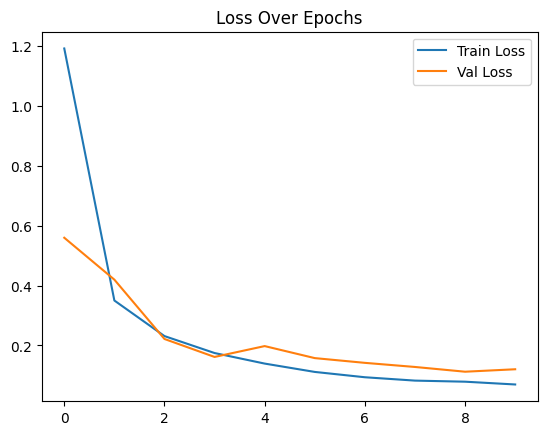


Example Predictions:

Index: 48
Predicted: 6 | True: 6
------------------------------


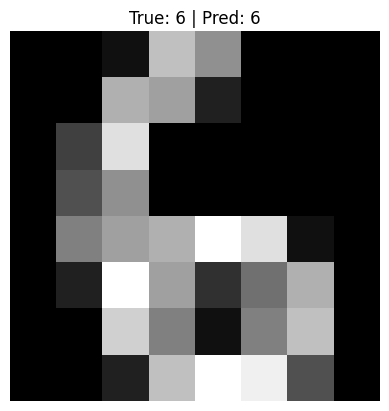

Index: 158
Predicted: 3 | True: 3
------------------------------


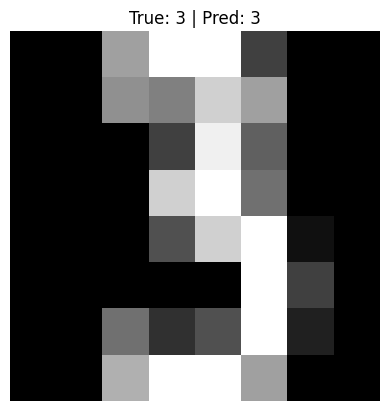

Index: 105
Predicted: 3 | True: 3
------------------------------


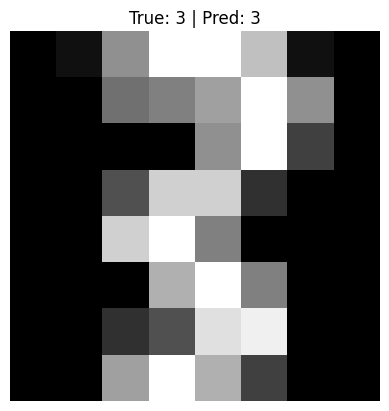

Index: 345
Predicted: 9 | True: 9
------------------------------


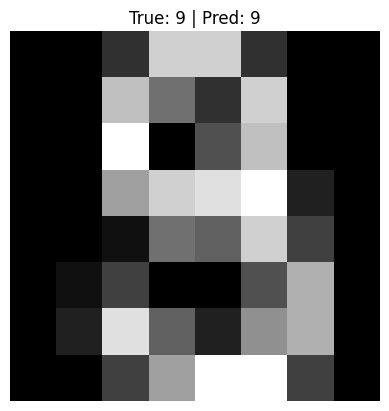

Index: 328
Predicted: 8 | True: 8
------------------------------


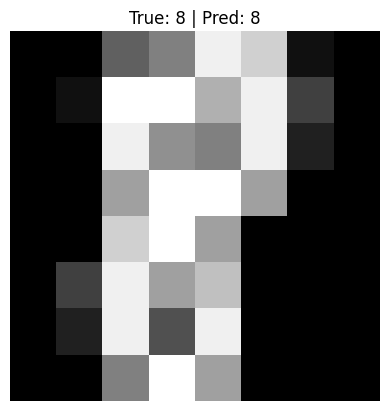

Index: 281
Predicted: 5 | True: 5
------------------------------


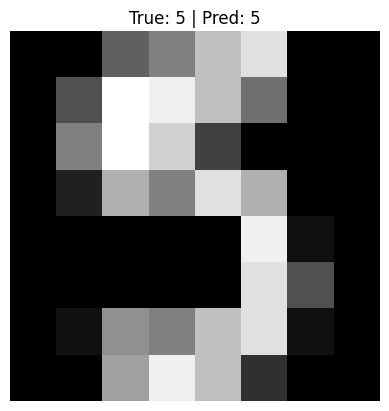

Index: 3
Predicted: 7 | True: 7
------------------------------


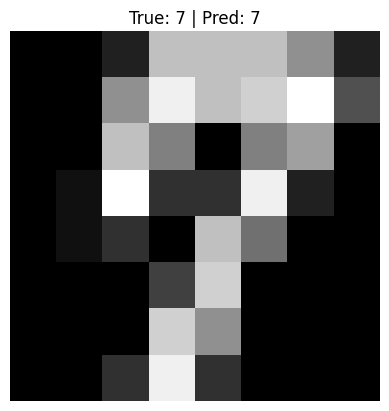

Index: 210
Predicted: 4 | True: 4
------------------------------


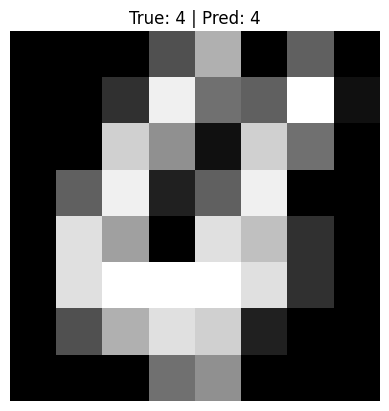

Index: 289
Predicted: 8 | True: 8
------------------------------


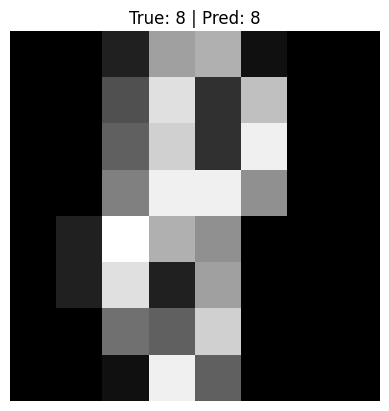

Index: 194
Predicted: 4 | True: 4
------------------------------


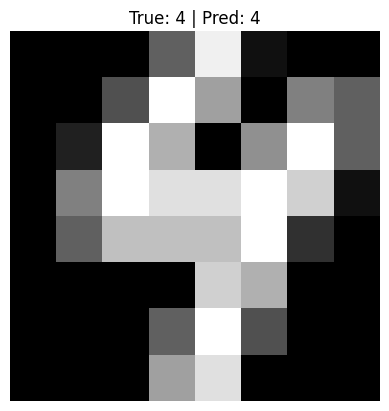

In [6]:
# 1. Load Data
digits = load_digits()
X, y = digits.data, digits.target

# 2. Preprocess Data
y_cat = to_categorical(y)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size = 0.2, random_state = 42
)

# 4. Build Keras MLP
model = Sequential([
    Dense(64, activation='relu', input_shape=(64,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='sgd', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# 5. Train
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose = True)

# 6. Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 7. Example Predictions
# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(history.history.keys())
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Over Epochs')
plt.show()

# Show a few examples
number_of_predictions = y_pred.shape[0]
number_of_examples = 10
print("\nExample Predictions:\n")


# Select randomly 10 images from prediction vector
examples = np.random.randint(0, number_of_predictions, size = number_of_examples)

for i in examples:
    print(f"Index: {i}")
    print(f"Predicted: {y_pred[i]} | True: {y_true[i]}")
    print("-" * 30)
    show_digit(i, X_test, y_true, y_pred)



